# Data Exploration, Data Cleaning, and Feature Engineering

This notebook consolidates the data exploration and data cleaning aspects of the project. It follows this logic: problem framing, data inspection, cleaning, feature engineering, baseline modelling, feature selection, and interpretation.

The objective is to explain which vehicle characteristics are most important for predicting:

- Fuel Consumption City (L/100 km)
- Fuel Consumption Hwy (L/100 km)
- Fuel Consumption Comb (L/100 km)


## 1. Imports and helper functions

We begin by importing the core libraries used throughout the notebook. A small helper function is included for reporting multi-output regression metrics clearly and consistently.


In [22]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.linear_model import LinearRegression, Lasso, LassoCV, MultiTaskLasso
from sklearn.feature_selection import RFECV
from sklearn.metrics import r2_score, mean_squared_error

sns.set_theme(style="whitegrid")

def rmse(y_true, y_pred, multioutput="raw_values"):
    return np.sqrt(mean_squared_error(y_true, y_pred, multioutput=multioutput))

def print_multioutput_metrics(y_true, y_pred, label="Model"):
    r2_vals = r2_score(y_true, y_pred, multioutput="raw_values")
    rmse_vals = rmse(y_true, y_pred)
    print(label)
    print("-" * len(label))
    for i, target in enumerate(y_true.columns):
        print(f"{target}")
        print(f"R2   = {r2_vals[i]:.4f}")
        print(f"RMSE = {rmse_vals[i]:.4f}\n")


## 2. Load the raw dataset

In [23]:
data_path = Path("../Data/CO2 Emissions_Canada.csv")
if not data_path.exists():
    raise FileNotFoundError(
        "The file 'CO2 Emissions_Canada.csv' was not found at '../Data/CO2 Emissions_Canada.csv'. "
        "Check that the dataset is inside the Data folder and that the notebook is being run from the Notebooks folder."
    )

df_raw = pd.read_csv(data_path)
df_raw.head()


,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


## 3. Initial inspection

Before any transformation, it is important to understand the dataset structure, column types, and basic quality issues such as missing values or duplicate rows.


In [24]:
print(f"Shape: {df_raw.shape}")
print("\nColumn names:")
print(df_raw.columns.tolist())

print("\nData types:")
print(df_raw.dtypes)

print("\nMissing values by column:")
print(df_raw.isnull().sum())

print("\nDuplicate rows:", df_raw.duplicated().sum())

print("\nUnique values in key categorical columns:")
for col in ["Vehicle Class", "Transmission", "Fuel Type"]:
    print(f"\n{col}:")
    print(df_raw[col].unique())


Shape: (7385, 12)

Column names:
['Make', 'Model', 'Vehicle Class', 'Engine Size(L)', 'Cylinders', 'Transmission', 'Fuel Type', 'Fuel Consumption City (L/100 km)', 'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)', 'Fuel Consumption Comb (mpg)', 'CO2 Emissions(g/km)']

Data types:
Make                                 object
Model                                object
Vehicle Class                        object
Engine Size(L)                      float64
Cylinders                             int64
Transmission                         object
Fuel Type                            object
Fuel Consumption City (L/100 km)    float64
Fuel Consumption Hwy (L/100 km)     float64
Fuel Consumption Comb (L/100 km)    float64
Fuel Consumption Comb (mpg)           int64
CO2 Emissions(g/km)                   int64
dtype: object

Missing values by column:
Make                                0
Model                               0
Vehicle Class                       0
Engine Size(L) 

The dataset contains $7,385$ observations and $12$ variables, providing a reasonably large sample for modelling fuel consumption and $CO_2$ emissions. The feature set includes a mix of categorical variables, such as Make, Model, Vehicle Class, Transmission, and Fuel Type, and numerical variables, such as engine size, cylinder count, fuel consumption measures, and $CO_2$ emissions. This combination suggests that preprocessing will need to account for both encoded categorical features and continuous numerical predictors.

Initial inspection of the data types shows that the variables are stored in appropriate formats. Categorical variables are represented as objects, while continuous and count-based variables are stored as numeric types. This means only limited, if any, type correction is likely to be required before analysis.

A missing-value check shows that there are no null values in any column. This is a strong indicator of good data completeness and means that imputation is not required at this stage. As a result, preprocessing can focus on structural issues such as duplicates, feature redundancy, and categorical encoding rather than handling incomplete records.

The dataset does, however, contain $1,103$ duplicate rows, which is substantial relative to the total number of observations. These duplicates may correspond to repeated vehicle entries and could bias both exploratory analysis and predictive modelling if retained. Removing duplicate records is therefore an important cleaning step to ensure that the models are trained on unique observations only.

Inspection of the categorical variables also provides useful context for later preprocessing. Vehicle Class contains a diverse range of car body and usage categories, Transmission includes many coded gearbox formats, and Fuel Type is represented using abbreviated letter codes. These variables may be informative predictors, but they will require encoding before they can be used in machine learning models. In particular, Transmission may benefit from feature engineering, since the codes appear to combine transmission type and gear count in a compact format.

Overall, the dataset appears clean and well-structured, with no missing data and appropriate variable types, but duplicate removal and categorical feature handling will be necessary before moving to modelling.

## 4. Data cleaning

The cleaning stage follows the following pipeline:

1. remove duplicate rows,
2. check for missing values,
3. retain observed outliers unless there is a strong reason to believe they are data-entry errors.

Outliers are not removed here because many vehicle types are genuinely extreme in relation to the rest of the dataset. In this setting, those observations are informative rather than necessarily erroneous. Note here that duplicates were dropped after dropping `Make` and `Model` as when these were included, the same cars with minor edits to name (yet exactly the same characteristics) may have skewed results.


In [42]:
df = df_raw.copy()
df = df.drop_duplicates().reset_index(drop=True)

df_clean = df.copy()
# Remove Make and Model, then remove duplicates created by that removal
df_clean = df_clean.drop(columns=["Make", "Model"]).drop_duplicates().reset_index(drop=True)

Path("../Data").mkdir(parents=True, exist_ok=True)
df_clean.to_csv(Path("../Data/Clean dataset.csv"), index=False)

print("Raw shape:", df_raw.shape)
print("Shape after exact duplicate removal:", df.shape)
print("Shape after dropping Make/Model and re-checking duplicates:", df_clean.shape)

print("\nMissing values after final cleaning:")
print(df_clean.isnull().sum())


Raw shape: (7385, 12)
Shape after exact duplicate removal: (6282, 12)
Shape after dropping Make/Model and re-checking duplicates: (4932, 10)

Missing values after final cleaning:
Vehicle Class                       0
Engine Size(L)                      0
Cylinders                           0
Transmission                        0
Fuel Type                           0
Fuel Consumption City (L/100 km)    0
Fuel Consumption Hwy (L/100 km)     0
Fuel Consumption Comb (L/100 km)    0
Fuel Consumption Comb (mpg)         0
CO2 Emissions(g/km)                 0
dtype: int64


## 5. Exploratory distributions and boxplots

Full-column visual inspection of distributions and whisker boxplots are given because they are useful for spotting skewness, unusual ranges, and candidate outliers before modelling.


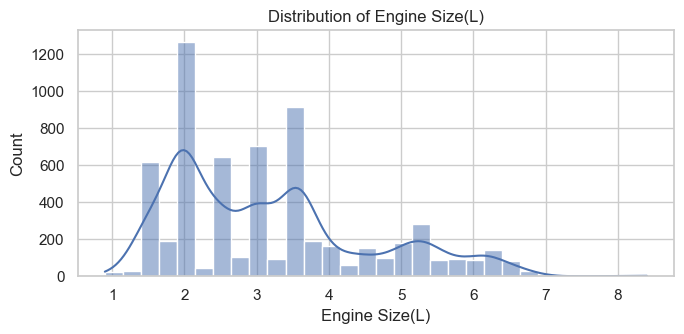

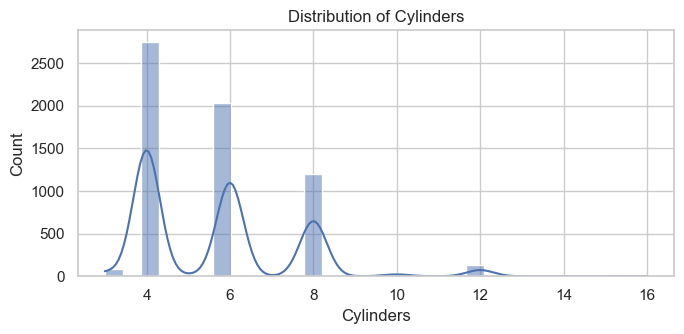

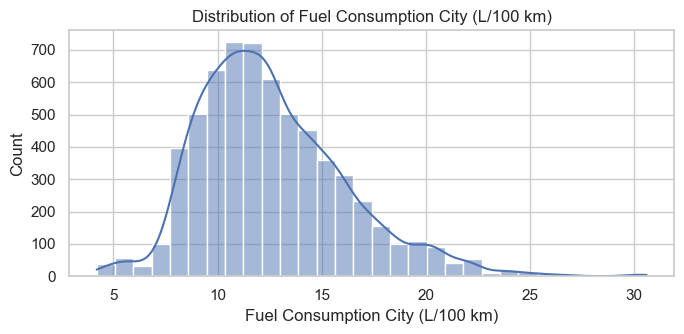

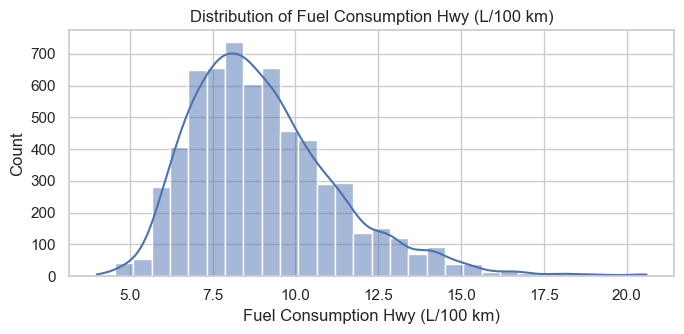

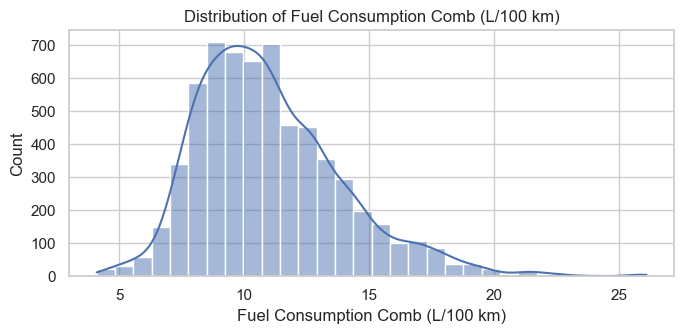

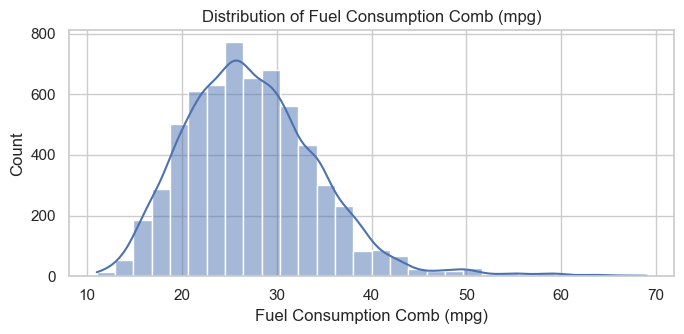

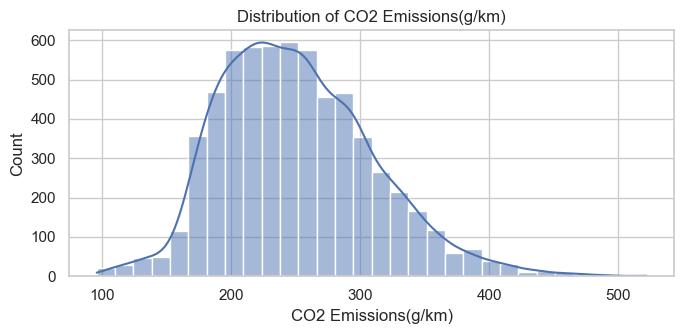

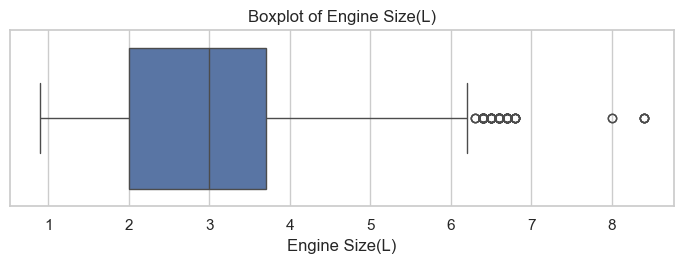

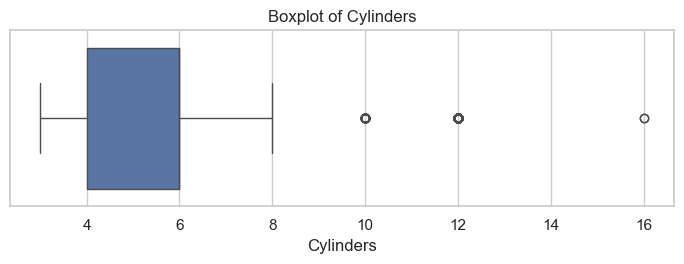

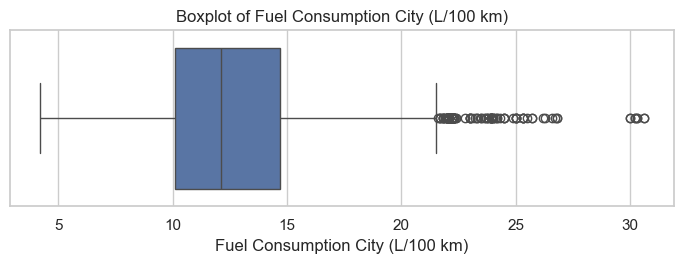

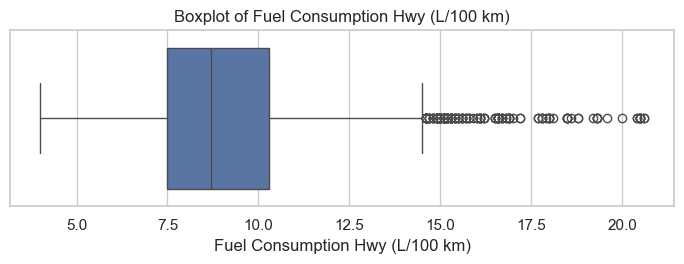

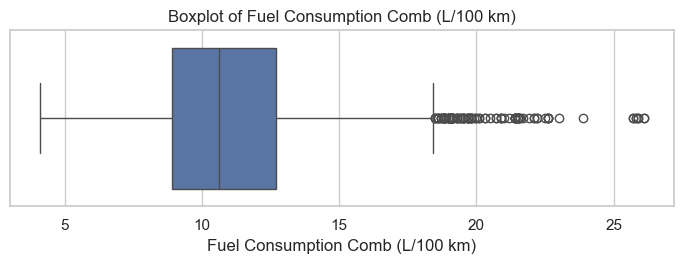

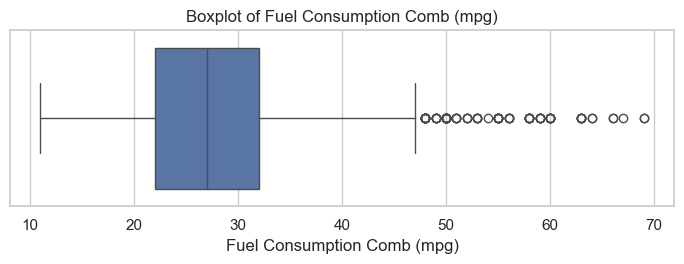

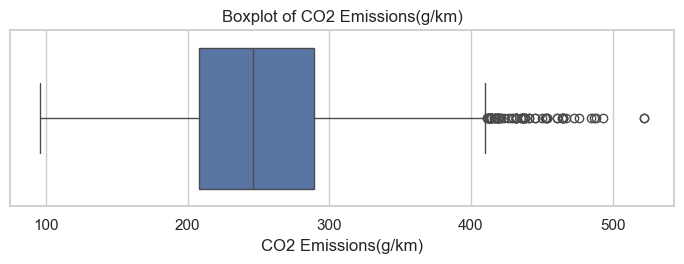

In [26]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

for col in numeric_cols:
    plt.figure(figsize=(7, 3.5))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

for col in numeric_cols:
    plt.figure(figsize=(7, 2.8))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()


## Distribution of Numerical Variables

The distribution plots suggest that the dataset is generally well-structured, with no obvious signs of severe data-quality issues such as impossible values, extreme anomalies, or highly irregular behaviour. Most variables fall within plausible ranges for passenger vehicles, so at this stage the plots are more useful for understanding the overall structure of the data than for identifying major cleaning problems.

Engine Size(L) and Cylinders should be interpreted with some caution. Although both are numeric variables, they take on a limited number of repeated values and represent vehicle design characteristics rather than smoothly varying continuous measurements. Their histograms are therefore highly discrete and multimodal, with peaks corresponding to common engine sizes and standard cylinder configurations such as $4$, $6$, and $8$. This is expected and does not indicate a problem, but it does mean that conventional distributional ideas such as normality are not especially informative for these variables.

The fuel consumption variables for city, highway, and combined driving are more conventionally distributed, though all show some positive skew. Most observations are concentrated in the lower-to-middle ranges, with a smaller number of vehicles extending into the upper tail at higher consumption levels. This is broadly consistent with expectations, as the majority of vehicles are likely to have moderate fuel use while a smaller subset of larger or less efficient vehicles consume substantially more fuel.

Fuel Consumption Comb (mpg) shows a related but reversed pattern, which is expected given that it is another representation of fuel efficiency. $CO_2$ Emissions(g/km) is broadly unimodal with a noticeable right tail, indicating that most vehicles lie within a moderate emissions range while a smaller number of vehicles produce much higher emissions. Overall, the plots do not suggest major concerns, but they do indicate that some variables are discrete in nature and that several of the fuel and emissions measures are likely to be strongly related, which will be relevant in later modelling and feature selection.

## Boxplot Analysis of Numerical Variables

The boxplots broadly reinforce the patterns observed in the histograms. There is no clear evidence of severe data-quality problems, but several variables contain observations that fall beyond the upper whiskers. In this context, these points should not automatically be treated as erroneous outliers, as they are likely to reflect genuine high-consumption, high-emission, or large-engine vehicles rather than errors in the dataset.

As with the histograms, Engine Size(L) and Cylinders should be interpreted cautiously. Both variables are discrete or semi-discrete design characteristics, so boxplots are of limited value for formal outlier detection. The apparent outlier values at the upper end mainly reflect less common but still plausible vehicle configurations, such as very large engines or unusually high cylinder counts, rather than obvious abnormalities.

The fuel consumption variables for city, highway, and combined driving all show right-skewed behaviour, with a larger concentration of observations in the lower and middle ranges and a number of high-end values extending beyond the whiskers. This pattern is consistent with the earlier distribution plots and suggests that a relatively small subset of vehicles is substantially less fuel-efficient than the majority. Fuel Consumption Comb (mpg) shows the same general behaviour in its own scale, with a wider spread toward the more extreme efficiency values.

CO2 Emissions(g/km) follows a similar pattern, with most observations concentrated in a central range and a number of higher-emission vehicles appearing beyond the upper whisker. This is not surprising given the close relationship between emissions and fuel consumption. Overall, the boxplots do not indicate any major issues requiring immediate removal of observations, but they do confirm that several variables are skewed and contain legitimate extreme values that may influence later modelling and should therefore be handled carefully.

## 6. Feature engineering and modelling design

The feature selection strategy follows this structure:

- predict the three fuel-consumption targets jointly,
- exclude `Fuel Consumption Comb (mpg)` because it is a direct transformation of the litre-per-100-km targets,
- exclude `CO2 Emissions(g/km)` from the main selected-feature modelling because it is determined largely by fuel consumption and therefore should not be used to predict it,
- preserve useful categorical information through one-hot encoding,
- split `Transmission` into a transmission type and a gear number, which captures more structure than treating the original text label as a single raw category.

This creates a cleaner and more interpretable feature space while still keeping strong predictive information.


In [28]:
target_cols = [
    "Fuel Consumption City (L/100 km)",
    "Fuel Consumption Hwy (L/100 km)",
    "Fuel Consumption Comb (L/100 km)"
]

df_model = df_clean.copy()

# Split transmission into transmission family and gear number
df_model["Transmission Type"] = df_model["Transmission"].str.extract(r"([A-Za-z]+)")
df_model["Gear num"] = pd.to_numeric(
    df_model["Transmission"].str.extract(r"(\d+)")[0],
    errors="coerce"
).fillna(0)

vehicle_class_map = {
    "MINICOMPACT": "SMALL",
    "SUBCOMPACT": "SMALL",
    "COMPACT": "SMALL",
    "TWO-SEATER": "SMALL",
    "STATION WAGON - SMALL": "MIDDLE",
    "MID-SIZE": "MIDDLE",
    "FULL-SIZE": "MIDDLE",
    "SUV - SMALL": "VAN",
    "SUV - STANDARD": "VAN",
    "STATION WAGON - MID-SIZE": "VAN",
    "PICKUP TRUCK - SMALL": "LARGE",
    "PICKUP TRUCK - STANDARD": "LARGE",
    "VAN - CARGO": "LARGE",
    "VAN - PASSENGER": "LARGE",
    "MINIVAN": "LARGE",
    "SPECIAL PURPOSE VEHICLE": "LARGE",
}
df_model["Type"] = df_model["Vehicle Class"].map(vehicle_class_map).fillna("Other")

# Main modelling dataset
drop_cols_main = [
    "Transmission",
    "Fuel Consumption Comb (mpg)",
    "CO2 Emissions(g/km)",
    "Vehicle Class",
] + target_cols

X = df_model.drop(columns=drop_cols_main)
y = df_model[target_cols].copy()

cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

print("Categorical columns:")
print(cat_cols)
print("\nNumeric columns:")
print(num_cols)
print("\nFeature matrix shape:", X.shape)
print("Target matrix shape:", y.shape)


Categorical columns:
['Fuel Type', 'Transmission Type', 'Type']

Numeric columns:
['Engine Size(L)', 'Cylinders', 'Gear num']

Feature matrix shape: (4932, 6)
Target matrix shape: (4932, 3)


## 7. Scatter plots for quick feature-target inspection

Here we display scatter plots to inspect the relationship between candidate predictors and the city/highway targets.


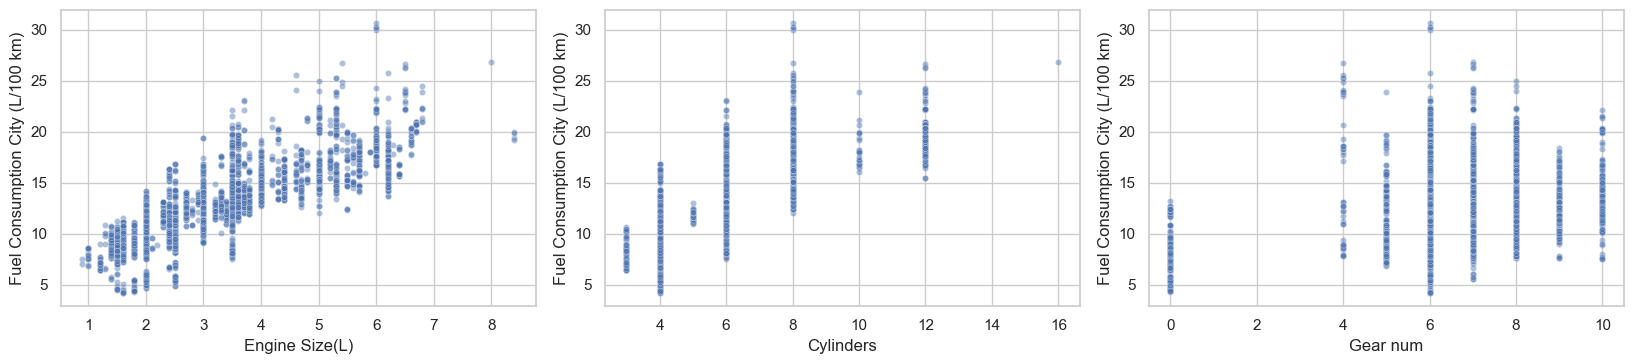

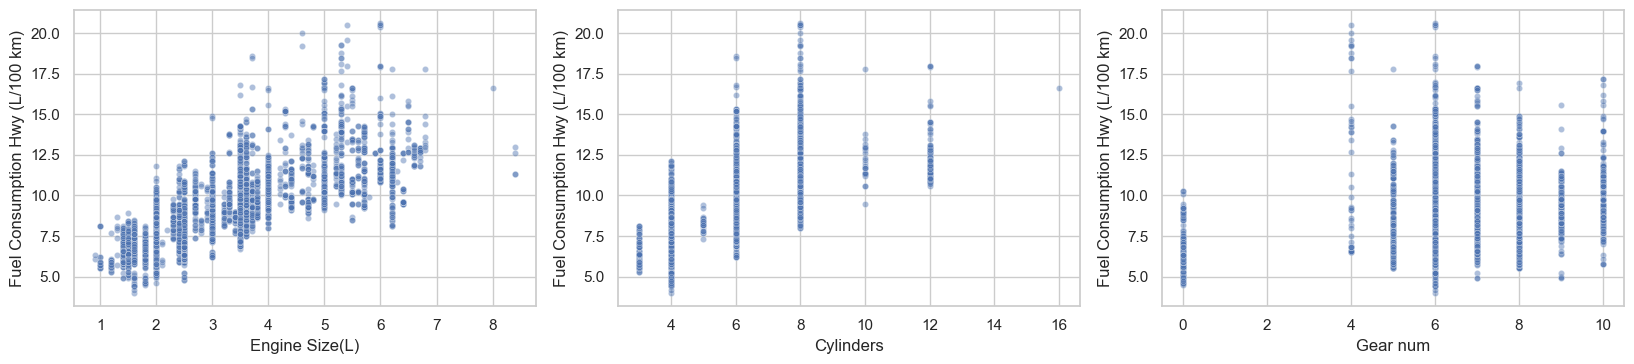

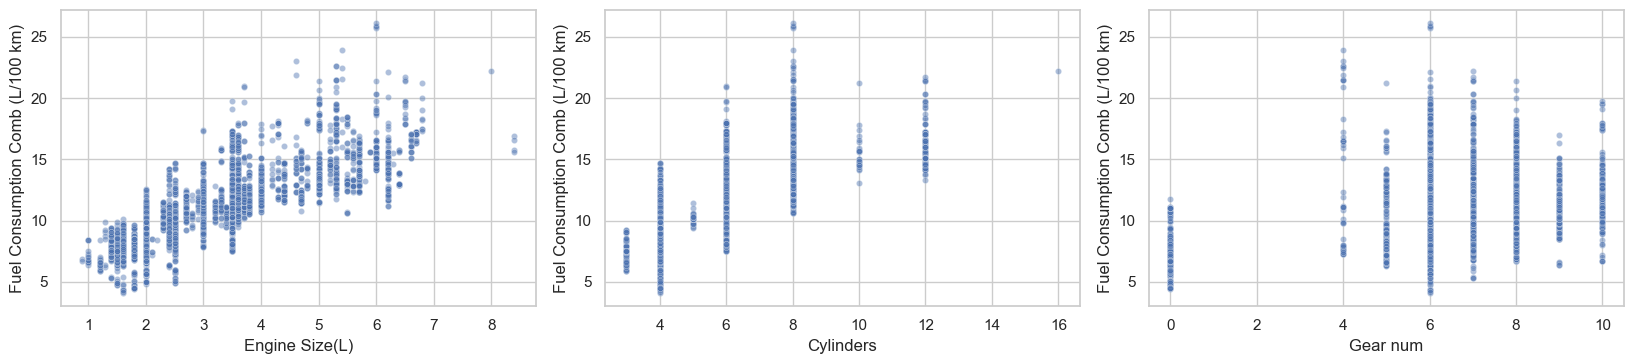

In [30]:
plot_targets = [
    "Fuel Consumption City (L/100 km)",
    "Fuel Consumption Hwy (L/100 km)",
    "Fuel Consumption Comb (L/100 km)"
]

for target in plot_targets:
    ncols = 3
    nrows = int(np.ceil(len(num_cols) / ncols))
    plt.figure(figsize=(5.5 * ncols, 3.8 * nrows))
    for idx, col in enumerate(num_cols, start=1):
        plt.subplot(nrows, ncols, idx)
        sns.scatterplot(data=pd.concat([X[num_cols], y], axis=1), x=col, y=target, alpha=0.45, s=20)
        plt.xlabel(col)
        plt.ylabel(target)
    plt.tight_layout()
    plt.show()


## Scatter Plot Analysis of Selected Predictors Against Fuel Consumption Targets

The scatter plots suggest that engine size and cylinder count both have clear positive relationships with fuel consumption across the city, highway, and combined targets. In each case, larger engines and higher cylinder counts are generally associated with higher fuel use, which is consistent with engineering expectations. The relationships are not perfectly linear, but the overall upward trend is clear enough to indicate that these variables are likely to be strong predictors in later modelling stages.

Engine Size(L) appears to show the smoothest and most consistent association with all three targets. As engine size increases, fuel consumption tends to rise in a fairly consistent fashion, although the spread of observations also becomes wider at higher engine sizes. This suggests that while engine size is informative, its effect may be moderated by other factors such as vehicle class, transmission characteristics, or fuel type. The relationship appears broadly similar across city, highway, and combined consumption, with no major structural differences.

Cylinders shows a similar positive relationship, with a step-like pattern because it takes a more limited number of discrete values. Though there is a noticeable amount of spread, the linear increase in fuel consumption with an increase in cylinder number is still clear. Vehicles with 3 or 4 cylinders are concentrated at lower consumption levels, while 6-, 8-, and higher-cylinder configurations tend to occupy higher ranges, with the average increasing between 6 and 8 but seeming to plateau thereafter. This reinforces the idea that cylinder count is likely to be useful, though its predictive contribution may overlap substantially with engine size.

The gear number variable shows a weaker and less interpretable relationship with the three targets. There is substantial vertical spread at most gear counts, and no simple monotonic pattern is evident. This suggests that gear number alone may not carry strong predictive power unless combined with oadditional information. It may therefore be more useful as part of a broader engineered transmission feature, or included in an interaction term, than as a standalone numerical predictor.

There are only modest differences between the three targets. The positive linear relationships with engine size and cylinders are visible for city, highway, and combined fuel consumption alike. Overall, the scatter plots do not suggest fundamentally different predictor-target relationships across the three targets.

## 8. Train-test split and preprocessing

We now divide the data into train and test subsets so that model performance can be assessed on unseen observations rather than only on the data used for fitting. An $80:20$ split is used, with a fixed `random_state` to ensure reproducibility of results. This provides a sufficiently large training set for learning while preserving a meaningful hold-out sample for evaluation.

At this stage, the feature matrix contains both numerical and categorical variables, so different preprocessing steps are required for each type. Numerical features are standardised using `StandardScaler`, which centres each variable around zero and scales it to unit variance. This is especially important for regularised models such as Lasso and MultiTaskLasso, since coefficients in these models are sensitive to the relative scale of the inputs. Standardisation makes coefficient magnitudes more comparable across variables.

Categorical features are transformed using `OneHotEncoder`, which converts each category into a binary indicator column. This allows the models to incorporate categorical information without imposing an artificial ordinal relationship between categories. The option `handle_unknown="ignore"` ensures that if a category appears in the test set that was not present in the training set, the transformation can still proceed safely without raising an error.

Both transformations are combined within a `ColumnTransformer`, which applies the correct preprocessing to each subset of columns in a single, consistent pipeline. This helps prevent manual errors, keeps the workflow reproducible, and ensures that the same fitted transformations learned from the training data are applied unchanged to the test data. Importantly, fitting the preprocessor only on the training set avoids data leakage, since no information from the test set is used when estimating scaling parameters or category mappings.

After preprocessing, the number of features increases from the original set to 33 transformed variables. This is because one-hot encoding expands each categorical column into multiple binary columns, one for each retained category level. The processed training and test matrices therefore contain the same number of columns, which confirms that the preprocessing has been applied consistently and that the resulting matrices are ready for downstream modelling.

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="drop"
)

to_dense = FunctionTransformer(lambda x: x.toarray() if hasattr(x, "toarray") else x)

X_train_proc = preprocess.fit_transform(X_train)
X_test_proc = preprocess.transform(X_test)
feature_names = preprocess.get_feature_names_out()

print("Processed training matrix shape:", X_train_proc.shape)
print("Processed test matrix shape:", X_test_proc.shape)
print("Number of transformed features:", len(feature_names))


Processed training matrix shape: (3945, 17)
Processed test matrix shape: (987, 17)
Number of transformed features: 17


## 9. Baseline model: multi-output linear regression

We begin modelling with a multi-output linear regression baseline, which provides a simple and interpretable reference point for all three fuel-consumption targets. Using a single model allows city, highway, and combined fuel consumption to be predicted within one consistent framework while establishing benchmark performance before moving to more specialised feature-selection methods.

In [32]:
baseline_model = Pipeline(steps=[
    ("prep", preprocess),
    ("linreg", LinearRegression())
])

baseline_model.fit(X_train, y_train)
y_pred_baseline = pd.DataFrame(
    baseline_model.predict(X_test),
    columns=y_test.columns,
    index=y_test.index
)

print_multioutput_metrics(y_test, y_pred_baseline, label="Baseline multi-output linear regression")


Baseline multi-output linear regression
---------------------------------------
Fuel Consumption City (L/100 km)
R2   = 0.8467
RMSE = 1.3897

Fuel Consumption Hwy (L/100 km)
R2   = 0.8354
RMSE = 0.9206

Fuel Consumption Comb (L/100 km)
R2   = 0.8523
RMSE = 1.1305



The baseline performance is strong across all three targets, with high $R^2$ values and relatively low RMSE. City and combined fuel consumption perform slightly better in terms of $R^2$, however highway fuel consumption records the lowest RMSE. This is not necessarily contradictory: RMSE measures prediction error, whereas $R^2$ measures the proportion of variance explained relative to the spread of the target. A lower RMSE for highway therefore likely reflects its narrower overall range, while the slightly lower $R^2$ suggests that the model explains a somewhat smaller share of its variation. Overall, these results indicate that the chosen predictors already provide a strong linear baseline, while still leaving scope for later methods to improve parsimony or predictive performance.

## 10. Residual behaviour and model assumptions

Residual plots are useful here because they show whether the errors remain centred around zero across the prediction range and can highlight any heteroscedasticity. This does not prove that every regression assumption is perfectly met, but it gives a practical diagnostic of fit quality.


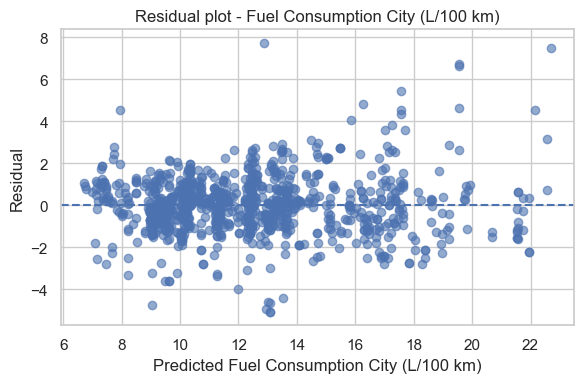

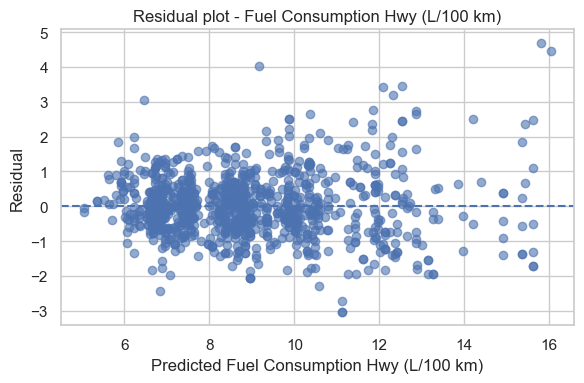

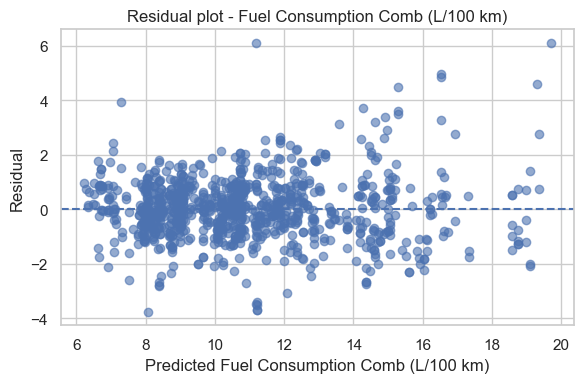

In [33]:
for target in y_test.columns:
    residuals = y_test[target] - y_pred_baseline[target]
    plt.figure(figsize=(6, 4))
    plt.scatter(y_pred_baseline[target], residuals, alpha=0.6)
    plt.axhline(0, linestyle="--")
    plt.xlabel(f"Predicted {target}")
    plt.ylabel("Residual")
    plt.title(f"Residual plot - {target}")
    plt.tight_layout()
    plt.show()


The residual plots suggest that the baseline linear model performs reasonably well overall, as the residuals for all three targets remain broadly centred around zero with no strong systematic pattern. This indicates that the model is capturing much of the structure in the data. At the same time, the residuals are not perfectly random, so the plots also provide some evidence that the relationships are not fully explained by a simple linear specification.

For all three targets, the spread of the residuals appears to increase slightly as the predicted values become larger. This suggests some degree of heteroscedasticity, meaning that prediction errors are somewhat less stable for vehicles with higher fuel consumption. There are also a small number of observations with relatively large positive or negative residuals, indicating that the model occasionally under- or over-predicts certain vehicles by a noticeable margin. These points do not appear extreme enough to suggest a major data problem, but they do indicate that some observations are harder to model than others.

The overall structure is broadly similar across city, highway, and combined fuel consumption, although the highway residuals appear slightly more compressed in absolute range, which is consistent with its lower RMSE. City and combined consumption show a somewhat wider spread at higher predicted values, suggesting that these targets may contain slightly greater unexplained variation in the upper range. Overall, the residual diagnostics support the use of linear regression as a strong baseline, while also suggesting that some nonlinearity or non-constant variance remains and could potentially be addressed in later modelling stages.

## 11. Pearson correlation analysis

The Pearson correlation heatmaps are used to identify features with strong linear relationships to the targets and the other features. Here the analysis is restricted to numeric variables, since Pearson correlation is designed for numeric, ordered inputs and would give arbitrary results for raw categorical features with no natural numerical scale.

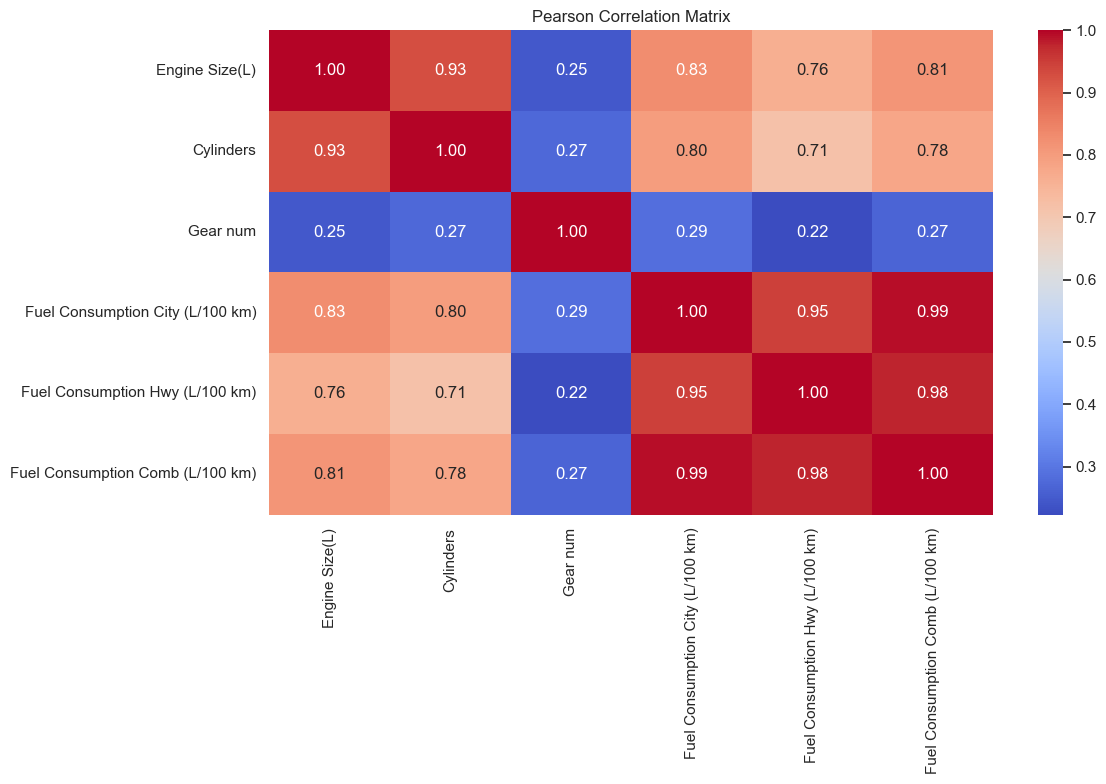


Absolute correlations with Fuel Consumption City (L/100 km):
Fuel Consumption City (L/100 km)    1.000000
Fuel Consumption Comb (L/100 km)    0.993661
Fuel Consumption Hwy (L/100 km)     0.947899
Engine Size(L)                      0.828350
Cylinders                           0.798763
Gear num                            0.286208
Name: Fuel Consumption City (L/100 km), dtype: float64

Absolute correlations with Fuel Consumption Hwy (L/100 km):
Fuel Consumption Hwy (L/100 km)     1.000000
Fuel Consumption Comb (L/100 km)    0.977402
Fuel Consumption City (L/100 km)    0.947899
Engine Size(L)                      0.760659
Cylinders                           0.714752
Gear num                            0.223102
Name: Fuel Consumption Hwy (L/100 km), dtype: float64

Absolute correlations with Fuel Consumption Comb (L/100 km):
Fuel Consumption Comb (L/100 km)    1.000000
Fuel Consumption City (L/100 km)    0.993661
Fuel Consumption Hwy (L/100 km)     0.977402
Engine Size(L)                 

In [34]:
corr_df = pd.concat([df_model[num_cols], y], axis=1)

plt.figure(figsize=(12, 8))
sns.heatmap(corr_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Pearson Correlation Matrix")
plt.tight_layout()
plt.show()

for target in y.columns:
    print(f"\nAbsolute correlations with {target}:")
    print(corr_df.corr()[target].abs().sort_values(ascending=False))


## Correlation Analysis of Numerical Variables

The Pearson correlation matrix highlights several strong linear relationships between the numerical variables. Most notably, engine size and cylinder count are very highly correlated, which is consistent with vehicle design expectations, as larger engines are often associated with more cylinders. This suggests that these two predictors may contain overlapping information and could introduce multicollinearity in linear models if both are retained without regularisation or feature selection.

The three fuel-consumption targets are also strongly correlated with one another. In particular, combined fuel consumption is almost perfectly correlated with both city and highway consumption, which is expected because it is derived from a combination of them and represents a summary efficiency measure. City and highway fuel consumption are also very highly correlated, indicating that vehicles which perform poorly in one setting tend to perform poorly in the other. These very high target-target correlations support the use of a multi-output framework, as the three responses clearly share substantial common structure.

Engine size and cylinder count both show strong positive correlations with the fuel-consumption targets, reinforcing the earlier scatter-plot findings that larger and more powerful engine configurations are associated with higher fuel use. These relationships appear slightly stronger for city and combined fuel consumption than for highway fuel consumption, though the differences are not especially large. This indicates that highway fuel consumption may be somewhat less strongly explained by the available predictors in relative term, though the difference is negligible.

By contrast, gear number shows only weak positive correlations with the other variables and with the targets. This suggests that, on its own, it is unlikely to be a particularly strong linear predictor of fuel consumption. However, this does not necessarily mean it is uninformative overall, as its usefulness may depend on interactions with other transmission-related features or on non-linear structure not captured by simple pairwise correlation.

Overall, the correlation matrix does not reveal any unexpected behaviour, but it does point to two important modelling considerations. First, the very high correlation between some predictors, particularly engine size and cylinders, raises the possibility of multicollinearity. Second, the extremely strong relationships between the three targets indicate substantial shared information, which helps justify modelling them jointly rather than entirely separately.

## 12. RFECV feature selection

Recursive Feature Elimination with cross-validation works on a single target at a time, so it is applied separately to each fuel-consumption outcome using the processed feature matrix.


In [35]:
X_train_dense = X_train_proc.toarray() if hasattr(X_train_proc, "toarray") else X_train_proc
X_test_dense = X_test_proc.toarray() if hasattr(X_test_proc, "toarray") else X_test_proc

kf = KFold(n_splits=5, shuffle=True, random_state=42)
rfecv_results = {}

for target in y_train.columns:
    selector = RFECV(
        estimator=LinearRegression(),
        step=1,
        cv=kf,
        scoring="neg_mean_squared_error",
        n_jobs=-1,
    )
    selector.fit(X_train_dense, y_train[target])

    ranking_df = pd.DataFrame({
        "Feature": feature_names,
        "Ranking": selector.ranking_,
        "Selected": selector.support_
    }).sort_values(["Ranking", "Feature"]).reset_index(drop=True)

    rfecv_results[target] = {
        "selector": selector,
        "ranking_df": ranking_df
    }

    print(f"\n{target}")
    print(f"Optimal number of features: {selector.n_features_}")
    display(ranking_df.head(32))



Fuel Consumption City (L/100 km)
Optimal number of features: 17


,Feature,Ranking,Selected
0,cat__Fuel Type_D,1,True
1,cat__Fuel Type_E,1,True
2,cat__Fuel Type_N,1,True
3,cat__Fuel Type_X,1,True
4,cat__Fuel Type_Z,1,True
5,cat__Transmission Type_A,1,True
6,cat__Transmission Type_AM,1,True
7,cat__Transmission Type_AS,1,True
8,cat__Transmission Type_AV,1,True
9,cat__Transmission Type_M,1,True



Fuel Consumption Hwy (L/100 km)
Optimal number of features: 17


,Feature,Ranking,Selected
0,cat__Fuel Type_D,1,True
1,cat__Fuel Type_E,1,True
2,cat__Fuel Type_N,1,True
3,cat__Fuel Type_X,1,True
4,cat__Fuel Type_Z,1,True
5,cat__Transmission Type_A,1,True
6,cat__Transmission Type_AM,1,True
7,cat__Transmission Type_AS,1,True
8,cat__Transmission Type_AV,1,True
9,cat__Transmission Type_M,1,True



Fuel Consumption Comb (L/100 km)
Optimal number of features: 17


,Feature,Ranking,Selected
0,cat__Fuel Type_D,1,True
1,cat__Fuel Type_E,1,True
2,cat__Fuel Type_N,1,True
3,cat__Fuel Type_X,1,True
4,cat__Fuel Type_Z,1,True
5,cat__Transmission Type_A,1,True
6,cat__Transmission Type_AM,1,True
7,cat__Transmission Type_AS,1,True
8,cat__Transmission Type_AV,1,True
9,cat__Transmission Type_M,1,True


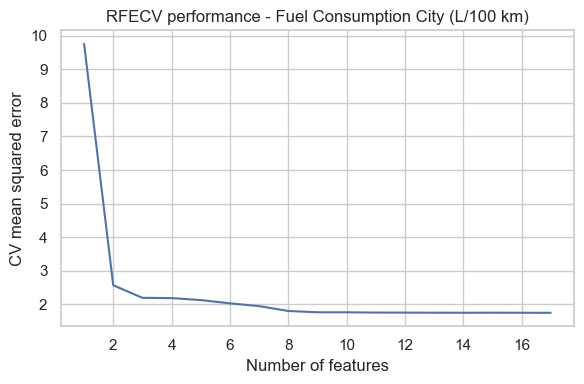

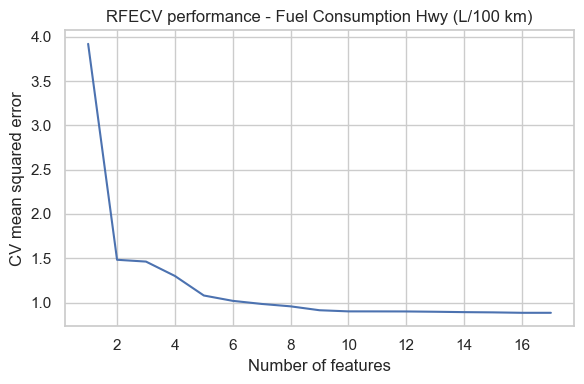

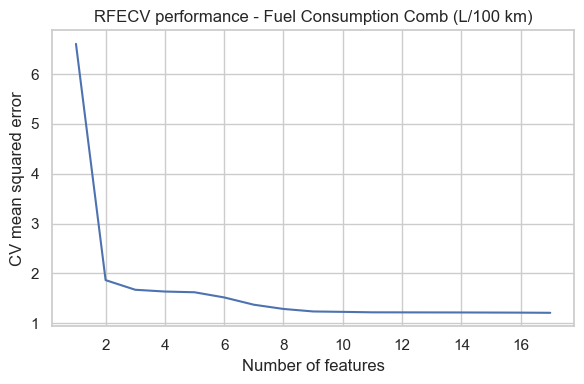

In [36]:
for target in y_train.columns:
    selector = rfecv_results[target]["selector"]
    cv_scores = -selector.cv_results_["mean_test_score"]

    plt.figure(figsize=(6, 4))
    plt.plot(range(1, len(cv_scores) + 1), cv_scores)
    plt.xlabel("Number of features")
    plt.ylabel("CV mean squared error")
    plt.title(f"RFECV performance - {target}")
    plt.tight_layout()
    plt.show()


## RFECV Feature Selection Results

The RFECV curves show that cross-validated mean squared error falls sharply when the first $4-5$ informative features are added, and then decreases more gradually as further features are included. This suggests that a relatively small subset of variables captures much of the main predictive signal, while additional features contribute smaller incremental improvements.

The optimal feature counts are nevertheless high for all three targets, with 16 features selected across the board. This is not because RFECV is designed to keep all features, but because the cross-validated linear regression performance continued to improve slightly as most features were retained. The result therefore suggests that many variables provide some marginal predictive value, even if only a smaller core set drives the largest reductions in error.

The selected subsets are highly consistent across the three targets. Fuel type, transmission type, broad vehicle-class variables, and the numerical variables are retained in most cases, indicating that both categorical and continuous information contribute to prediction. Overall, the RFECV results suggest broad predictive relevance across the transformed feature set rather than strong evidence for substantial dimensionality reduction.

## 13. Lasso feature selection

Lasso regularisation complements RFECV well. RFECV ranks variables by iterative elimination, whereas Lasso can shrink weak coefficients directly to zero. That makes it especially useful for a high-dimensional encoded feature space.


In [37]:
lasso_results = {}

for target in y_train.columns:
    lasso_cv = LassoCV(cv=kf, max_iter=10000, n_jobs=-1, random_state=42)
    lasso_cv.fit(X_train_dense, y_train[target])
    best_alpha = lasso_cv.alpha_

    lasso = Lasso(alpha=best_alpha, max_iter=10000, random_state=42)
    lasso.fit(X_train_dense, y_train[target])

    pred = lasso.predict(X_test_dense)
    coefs = pd.Series(lasso.coef_, index=feature_names)
    coef_df = (
        pd.DataFrame({
            "Feature": feature_names,
            "Coefficient": lasso.coef_,
            "Importance": np.abs(lasso.coef_)
        })
        .sort_values("Importance", ascending=False)
        .reset_index(drop=True)
    )

    lasso_results[target] = {
        "alpha": best_alpha,
        "model": lasso,
        "coef_df": coef_df,
        "r2": r2_score(y_test[target], pred),
        "rmse": float(np.sqrt(mean_squared_error(y_test[target], pred))),
    }

    print(f"\n{target}")
    print(f"Best alpha: {best_alpha:.6f}")
    print(f"R2:   {lasso_results[target]['r2']:.4f}")
    print(f"RMSE: {lasso_results[target]['rmse']:.4f}")
    display(coef_df.head(20))



Fuel Consumption City (L/100 km)
Best alpha: 0.002846
R2:   0.8468
RMSE: 1.3891


,Feature,Coefficient,Importance
0,cat__Fuel Type_E,4.369517,4.369517
1,cat__Transmission Type_AV,-2.063577,2.063577
2,cat__Fuel Type_D,-2.056317,2.056317
3,num__Engine Size(L),1.440762,1.440762
4,num__Cylinders,1.052176,1.052176
5,cat__Type_LARGE,0.862552,0.862552
6,cat__Fuel Type_X,-0.700919,0.700919
7,cat__Type_SMALL,-0.615230,0.615230
8,cat__Type_MIDDLE,-0.555581,0.555581
9,cat__Type_VAN,0.529680,0.529680



Fuel Consumption Hwy (L/100 km)
Best alpha: 0.001678
R2:   0.8356
RMSE: 0.9201


,Feature,Coefficient,Importance
0,cat__Fuel Type_E,2.865924,2.865924
1,cat__Fuel Type_D,-1.765562,1.765562
2,cat__Type_LARGE,1.371623,1.371623
3,cat__Transmission Type_AV,-0.882428,0.882428
4,num__Engine Size(L),0.786687,0.786687
5,cat__Type_MIDDLE,-0.781932,0.781932
6,cat__Type_SMALL,-0.759855,0.759855
7,cat__Type_VAN,0.671272,0.671272
8,num__Cylinders,0.589040,0.589040
9,cat__Fuel Type_X,-0.587984,0.587984



Fuel Consumption Comb (L/100 km)
Best alpha: 0.002320
R2:   0.8524
RMSE: 1.1301


,Feature,Coefficient,Importance
0,cat__Fuel Type_E,3.691372,3.691372
1,cat__Fuel Type_D,-1.917245,1.917245
2,cat__Transmission Type_AV,-1.590827,1.590827
3,num__Engine Size(L),1.144774,1.144774
4,cat__Type_LARGE,1.088445,1.088445
5,num__Cylinders,0.844927,0.844927
6,cat__Type_SMALL,-0.677114,0.677114
7,cat__Type_MIDDLE,-0.657257,0.657257
8,cat__Fuel Type_X,-0.649494,0.649494
9,cat__Type_VAN,0.591126,0.591126


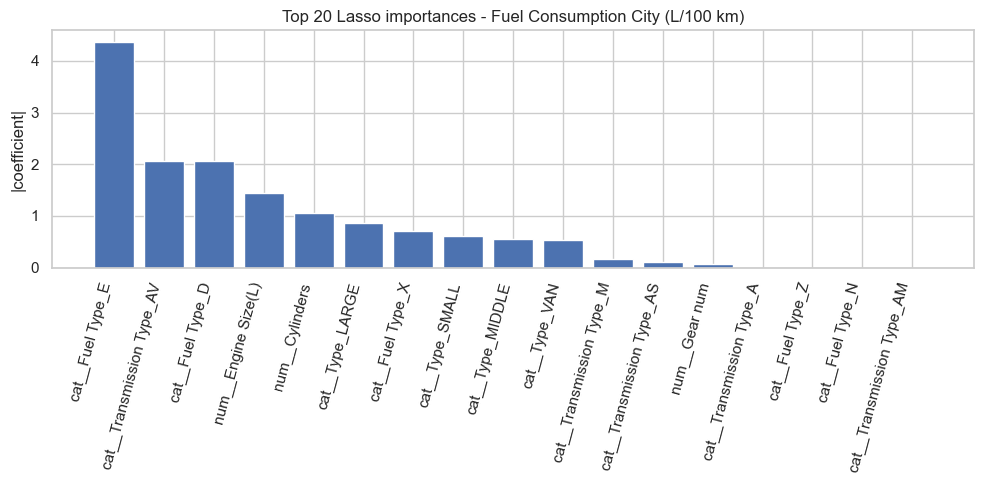

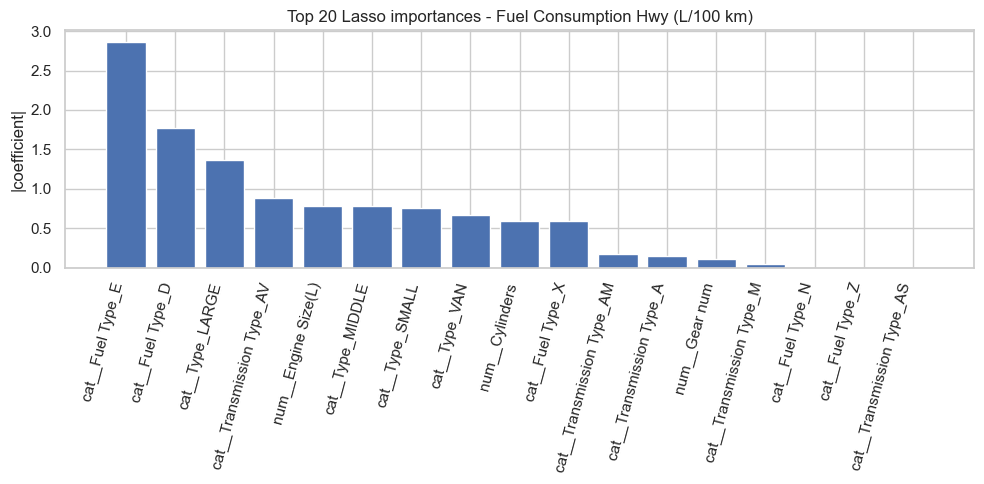

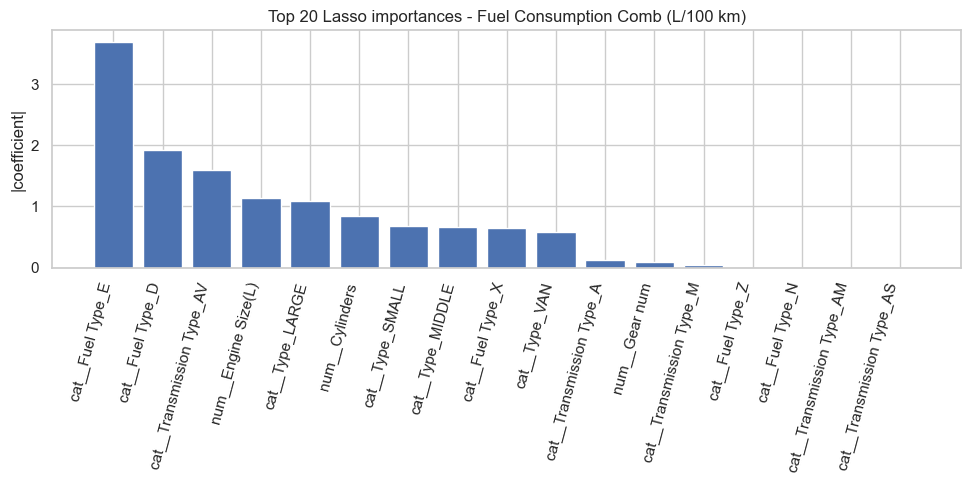

In [38]:
top_k = 20

for target in y_train.columns:
    plot_df = lasso_results[target]["coef_df"].head(top_k)

    plt.figure(figsize=(10, 5))
    plt.bar(plot_df["Feature"], plot_df["Importance"])
    plt.xticks(rotation=75, ha="right")
    plt.ylabel("|coefficient|")
    plt.title(f"Top {top_k} Lasso importances - {target}")
    plt.tight_layout()
    plt.show()


## Lasso Regression Results

The Lasso models perform similarly to the baseline linear regression, with only a slight reduction in predictive accuracy across the three fuel-consumption targets. This pattern is plausible, since Lasso introduces regularisation that shrinks less useful coefficients toward zero in exchange for a simpler and potentially more stable model, indicating that even less influential variables have some predictive capacity. The best $\alpha$ values are all quite small, which suggests that only a modest amount of shrinkage is needed and that most of the predictive signal is already well aligned with a linear specification.

Across all three targets, the most influential predictors are consistent. Fuel type, grouped vehicle-size classes, and transmission type all appear prominently, while the numerical variables Engine Size(L) and Cylinders also remain among the strongest retained features. This indicates that both categorical structure and numerical features contribute meaningfully to fuel-consumption prediction, rather than one type of variable dominating the model entirely.

The coefficient patterns are also broadly intuitive. Larger vehicle types and van-related classes tend to be associated with increased fuel consumption, while engine size and cylinder count have positive coefficients, reinforcing the expectation that larger and more powerful vehicles consume more fuel. Some fuel-type and transmission categories carry negative coefficients relative to the reference categories, indicating lower predicted consumption after controlling for the rest of the feature set. The rankings are broadly similar across city, highway, and combined fuel consumption, with highway again appearing slightly less strongly explained than the other two targets. Overall, the Lasso results provide a more selective and interpretable model while preserving performance close to the unregularised baseline.

## 14. MultiTaskLasso on the full three-target problem

Here, we model the three fuel-consumption targets jointly, rather than fitting three entirely separate models. This is motivated by the strong conceptual and empirical linkage between city, highway, and combined consumption: they measure the same underlying efficiency characteristics of a vehicle under different driving conditions, and are therefore expected to share many of the same drivers (e.g., engine size, cylinders, vehicle class, fuel type, transmission type). We use a `MultiTaskLasso` pipeline to assess all three targets simultaneously while encouraging a shared sparsity pattern, so the model tends to retain predictors that are useful across the full problem and discard those that add little consistent value.

In [39]:
multitask_pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("dense", to_dense),
    ("lasso", MultiTaskLasso(alpha=0.01, max_iter=10000, random_state=42))
])

multitask_pipe.fit(X_train, y_train)

y_pred_mtl = pd.DataFrame(
    multitask_pipe.predict(X_test),
    columns=y_test.columns,
    index=y_test.index
)

print_multioutput_metrics(y_test, y_pred_mtl, label="MultiTaskLasso")


MultiTaskLasso
--------------
Fuel Consumption City (L/100 km)
R2   = 0.8468
RMSE = 1.3890

Fuel Consumption Hwy (L/100 km)
R2   = 0.8351
RMSE = 0.9214

Fuel Consumption Comb (L/100 km)
R2   = 0.8523
RMSE = 1.1307



In [40]:
mtl_feature_names = multitask_pipe.named_steps["prep"].get_feature_names_out()
mtl_coefs = np.atleast_2d(multitask_pipe.named_steps["lasso"].coef_)

coef_df = pd.DataFrame({"feature": mtl_feature_names})
for i, target in enumerate(y_train.columns):
    coef_df[f"coef_{target}"] = mtl_coefs[i, :]
    coef_df[f"imp_{target}"] = np.abs(mtl_coefs[i, :])

coef_df.head()


,feature,coef_Fuel Consumption City (L/100 km),imp_Fuel Consumption City (L/100 km),coef_Fuel Consumption Hwy (L/100 km),imp_Fuel Consumption Hwy (L/100 km),coef_Fuel Consumption Comb (L/100 km),imp_Fuel Consumption Comb (L/100 km)
0,num__Engine Size(L),1.450883,1.450883,0.802180,0.802180,1.160031,1.160031
1,num__Cylinders,1.043012,1.043012,0.580151,0.580151,0.833794,0.833794
2,num__Gear num,-0.064654,0.064654,-0.096265,0.096265,-0.078984,0.078984
3,cat__Fuel Type_D,-1.890567,1.890567,-1.576087,1.576087,-1.740226,1.740226
4,cat__Fuel Type_E,4.306271,4.306271,2.843589,2.843589,3.649332,3.649332


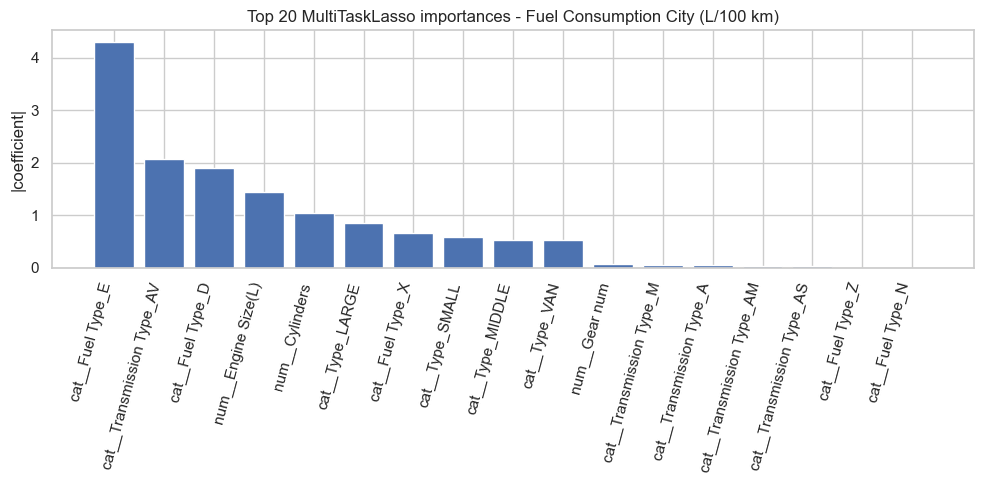


Features forced to zero for Fuel Consumption City (L/100 km): 2
['cat__Fuel Type_N', 'cat__Fuel Type_Z'] 


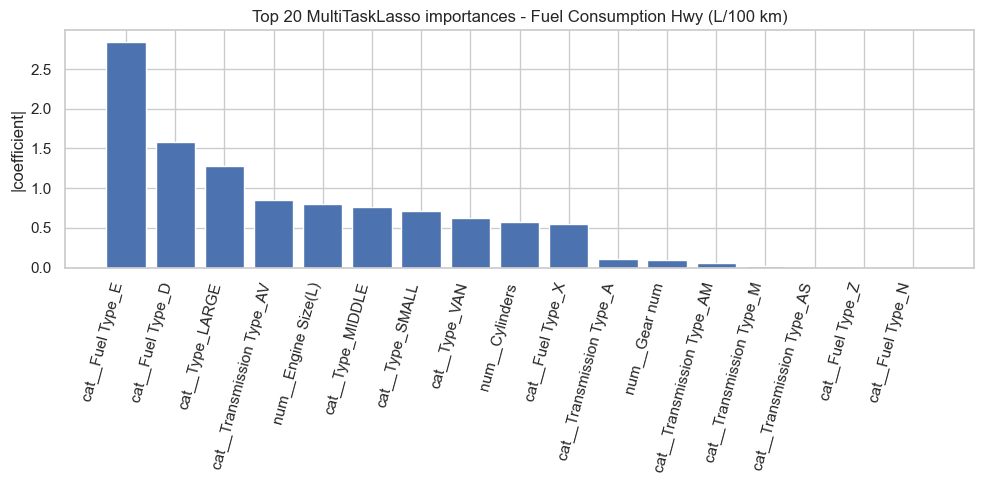


Features forced to zero for Fuel Consumption Hwy (L/100 km): 2
['cat__Fuel Type_N', 'cat__Fuel Type_Z'] 


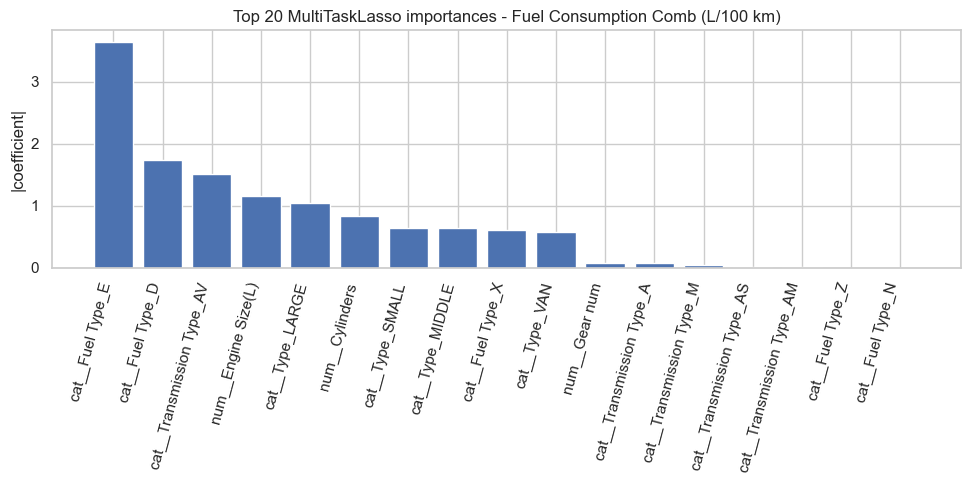


Features forced to zero for Fuel Consumption Comb (L/100 km): 2
['cat__Fuel Type_N', 'cat__Fuel Type_Z'] 


In [41]:
top_k = 20

for target in y_train.columns:
    plot_df = coef_df[["feature", f"imp_{target}"]].sort_values(f"imp_{target}", ascending=False).head(top_k)

    plt.figure(figsize=(10, 5))
    plt.bar(plot_df["feature"], plot_df[f"imp_{target}"])
    plt.xticks(rotation=75, ha="right")
    plt.ylabel("|coefficient|")
    plt.title(f"Top {top_k} MultiTaskLasso importances - {target}")
    plt.tight_layout()
    plt.show()

    zeros = coef_df.loc[coef_df[f"coef_{target}"] == 0, "feature"].tolist()
    print(f"\nFeatures forced to zero for {target}: {len(zeros)}")
    print(zeros[:30], "..." if len(zeros) > 30 else "")


## MultiTaskLasso results on the three-target problem

MultiTaskLasso models city, highway, and combined fuel consumption jointly, enforcing a shared sparsity pattern across all three outputs. Performance remains strong across the targets, with city and combined slightly better than highway, and only a modest reduction relative to the unregularised baseline and single-target Lasso. This behaviour is consistent with the extra constraint imposed by MultiTaskLasso: it is not free to choose a different feature set for each target, and instead learns one coherent structure that generalises across driving conditions.

The strongest retained effects are highly consistent across the three targets. Engine Size(L) and Cylinders remain important positive predictors, reinforcing that larger engine configurations are associated with increased fuel consumption. Among categorical variables, fuel type, transmission type, and the broader vehicle-class groupings dominate the learned structure, with effects such as `Fuel Type_E`, `Transmission Type_AV`, and the grouped size indicators (`Type_LARGE`, `Type_MIDDLE`, `Type_SMALL`, `Type_VAN`) appearing repeatedly among the largest coefficients. Using the broader class groupings improves interpretability by concentrating signal into a smaller number of meaningful categories, rather than spreading it across many sparse one-hot vehicle-class dummies.

A key property of MultiTaskLasso is that it forces exactly the same predictors to zero across all targets when they do not provide consistent shared value. In this run, only one feature is removed across the full three-target problem: `cat__Transmission Type_AS`. The fact that almost all features are retained suggests that most predictors contribute at least some shared predictive information across city, highway, and combined consumption, while MultiTaskLasso still provides a disciplined way to identify any variables that add negligible value consistently across the three outputs.

## Conclusion

This work focused on data preprocessing and exploratory analysis of key vehicle variables in order to support feature selection for predicting city, highway, and combined fuel consumption. The dataset was found to be complete (no missing values) and numerically plausible, but a substantial number of duplicate rows were identified and removed to avoid distorting both descriptive statistics and downstream selection results. Categorical variables were inspected to understand their levels and structure, and preprocessing was designed to treat mixed data types appropriately: numerical features were standardised and categorical features were one-hot encoded to preserve information without imposing artificial ordering.

Exploratory analysis provided initial evidence for which variables are likely to be informative. Distributional and boxplot checks indicated that several predictors (notably engine size and cylinders) behave as discrete design characteristics rather than smooth continuous quantities, while fuel-consumption and emissions variables exhibit expected skew and legitimate high-end extremes. Scatter plots and correlation analysis showed clear positive relationships between engine characteristics and fuel consumption, weak standalone association for gear count, and very strong dependence between the three fuel-consumption targets themselves. Together, these diagnostics motivate careful handling of redundancy among predictors.

Feature selection was then assessed using RFECV and regularised linear models. RFECV showed rapid early improvements in cross-validated error but ultimately selected a feature set equivalent to the full transformed representation, indicating that many predictors add incremental predictive value rather than a small subset dominating entirely. Single-target Lasso provided a complementary view by shrinking weaker coefficients and highlighting the most influential predictors, consistently elevating fuel type, transmission type, vehicle class groupings, and engine characteristics. MultiTaskLasso extended this to the joint three-target setting, encouraging a shared sparsity structure across the correlated outputs; with the broader vehicle-class groupings used here, it retained almost all predictors and forced only `cat__Transmission Type_AS` to zero across all targets, suggesting limited scope for aggressive dimensionality reduction under a linear specification.

Overall, the analysis establishes a cleaned dataset, an appropriate preprocessing strategy, and a clear understanding of which variables and encoded categories are most informative for fuel-consumption prediction. These results provide a justified feature set and baseline interpretive evidence for subsequent modelling stages, while also indicating that regularisation may be more useful for stabilisation and interpretability than for substantial feature elimination in this particular dataset.